#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from tree_sitter_languages import get_parser

from concurrent.futures import ThreadPoolExecutor

import math
from collections import Counter

import matplotlib.pyplot as plt


#### Loading Dataset

In [2]:
train_df = pd.read_parquet("../data/task_a/train.parquet")
val_df   = pd.read_parquet("../data/task_a/val.parquet")
test_df  = pd.read_parquet("../data/task_a/test_sample.parquet")

print(train_df.shape, val_df.shape, test_df.shape)

(500000, 4) (100000, 4) (1000, 4)


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### Setup tree-sitter Parsers

In [4]:
parsers = {
    "Python": get_parser("python"),
    "Java": get_parser("java"),
    "C++": get_parser("cpp")
}

#### AST Scalar Feature Extraction

In [5]:
def extract_ast_features(code, language):

    parser = parsers.get(language)

    if parser is None:
        return [0]*15

    try:
        tree = parser.parse(bytes(code, "utf8"))
        root = tree.root_node
    except:
        return [0]*15

    stack = [(root,0)]

    total_nodes = 0
    leaf_nodes = 0
    depths = []
    children_counts = []
    node_types = []

    decision_nodes = 0
    function_calls = 0
    call_types = set()

    while stack:

        node, depth = stack.pop()

        total_nodes += 1
        depths.append(depth)

        node_types.append(node.type)

        children = node.children
        children_counts.append(len(children))

        if len(children) == 0:
            leaf_nodes += 1

        if node.type in ["if_statement","for_statement","while_statement"]:
            decision_nodes += 1

        if "call" in node.type:
            function_calls += 1
            call_types.add(node.type)

        for child in children:
            stack.append((child, depth+1))

    max_depth = max(depths) if depths else 0
    avg_depth = np.mean(depths) if depths else 0
    depth_var = np.var(depths) if depths else 0

    leaf_ratio = leaf_nodes/(total_nodes+1)

    avg_branch = np.mean(children_counts) if children_counts else 0
    max_children = max(children_counts) if children_counts else 0

    cyclomatic = decision_nodes + 1

    unique_types = len(set(node_types))

    counts = Counter(node_types)
    probs = [v/total_nodes for v in counts.values()]

    entropy = -sum(p*math.log(p) for p in probs)

    unique_calls = len(call_types)

    internal_nodes = total_nodes - leaf_nodes

    return [
        max_depth,
        avg_depth,
        depth_var,
        total_nodes,
        leaf_nodes,
        leaf_ratio,
        avg_branch,
        max_children,
        cyclomatic,
        decision_nodes,
        unique_types,
        entropy,
        function_calls,
        unique_calls,
        internal_nodes
    ]

#### Parallel Feature Extraction

In [6]:
def parallel_feature_extraction(df, max_workers=12):

    codes = df["code"].tolist()
    langs = df["language"].tolist()

    tasks = list(zip(codes,langs))

    features = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:

        for feat in tqdm(executor.map(lambda x: extract_ast_features(*x), tasks),
                         total=len(tasks)):
            features.append(feat)

    return np.array(features)

#### Extracting Features for Entire Dataset

In [ ]:
X_train = parallel_feature_extraction(train_df)

X_val   = parallel_feature_extraction(val_df)

X_test  = parallel_feature_extraction(test_df)

#### Extracting Labels

In [7]:
y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

#### saving Features

In [ ]:
np.save("../data/X_train_ast_scalars.npy", X_train)
np.save("../data/X_val_ast_scalars.npy", X_val)
np.save("../data/X_test_ast_scalars.npy", X_test)

#### using saved npy

In [8]:
X_train = np.load("../data/X_train_ast_scalars.npy")
X_val   = np.load("../data/X_val_ast_scalars.npy")
X_test  = np.load("../data/X_test_ast_scalars.npy")

#### Verifying Feature Matrix

In [9]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(500000, 15)
(100000, 15)
(1000, 15)


#### Import ML related Libraries

In [10]:
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

## Train Models

### Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### SVM (Linear SVM for large dataset)

In [12]:
svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


### CatBoost

In [13]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=100
)

cat_model.fit(X_train, y_train)

0:	learn: 0.6654927	total: 192ms	remaining: 1m 35s
100:	learn: 0.4971802	total: 3.04s	remaining: 12s
200:	learn: 0.4794115	total: 5.86s	remaining: 8.72s
300:	learn: 0.4687011	total: 8.84s	remaining: 5.84s
400:	learn: 0.4617273	total: 11.7s	remaining: 2.88s
499:	learn: 0.4563206	total: 14.4s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, verbose=100)

### Evaluation Function

In [14]:
def evaluate_model(model, X_test, y_test, model_name):

    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        probs = model.decision_function(X_test)

    print("\n======", model_name, "======")

    acc = accuracy_score(y_test, preds)
    f1_bin = f1_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    prec = precision_score(y_test, preds, average="macro")
    rec = recall_score(y_test, preds, average="macro")
    auc = roc_auc_score(y_test, probs)

    print("Accuracy:", acc)
    print("Binary F1:", f1_bin)
    print("Macro F1:", f1_macro)
    print("Macro Precision:", prec)
    print("Macro Recall:", rec)
    print("ROC AUC:", auc)

    print("\nClassification Report")
    print(classification_report(y_test, preds))

    return probs

### Evaluating All Models

#### validation Data

In [15]:
rf_val_probs = evaluate_model(rf_model, X_val, y_val, "Random Forest (Validation)")

svm_val_probs = evaluate_model(svm_model, X_val, y_val, "SVM (Validation)")

cat_val_probs = evaluate_model(cat_model, X_val, y_val, "CatBoost (Validation)")


====== Random Forest (Validation) ======
Accuracy: 0.77257
Binary F1: 0.7639126778985394
Macro F1: 0.7722637656134927
Macro Precision: 0.7793076711037838
Macro Recall: 0.7759094575382548
ROC AUC: 0.8587353088657546

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.85      0.78     47695
           1       0.84      0.70      0.76     52305

    accuracy                           0.77    100000
   macro avg       0.78      0.78      0.77    100000
weighted avg       0.78      0.77      0.77    100000


====== SVM (Validation) ======
Accuracy: 0.69
Binary F1: 0.6705562286127229
Macro F1: 0.6889163836497166
Macro Precision: 0.6991488842097875
Macro Recall: 0.6941961345671435
ROC AUC: 0.7638440389901022

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.79      0.71     47695
           1       0.75      0.60      0.67     52305

    accuracy                           0.69 

#### Test Data

In [16]:
rf_probs = evaluate_model(rf_model, X_test, y_test, "Random Forest")

svm_probs = evaluate_model(svm_model, X_test, y_test, "SVM")

cat_probs = evaluate_model(cat_model, X_test, y_test, "CatBoost")


====== Random Forest ======
Accuracy: 0.359
Binary F1: 0.3770651117589893
Macro F1: 0.35846046525127634
Macro Precision: 0.5456051264997058
Macro Recall: 0.5411551846529424
ROC AUC: 0.5970041149413348

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.21      0.34       777
           1       0.24      0.87      0.38       223

    accuracy                           0.36      1000
   macro avg       0.55      0.54      0.36      1000
weighted avg       0.71      0.36      0.35      1000


====== SVM ======
Accuracy: 0.399
Binary F1: 0.3516720604099245
Macro F1: 0.3957801122180098
Macro Precision: 0.5144156941031941
Macro Recall: 0.5173370038840891
ROC AUC: 0.5381771906435584

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.30      0.44       777
           1       0.23      0.73      0.35       223

    accuracy                           0.40      1000
   macro avg    

### ROC Curve Visualization

#### ROC for Validation

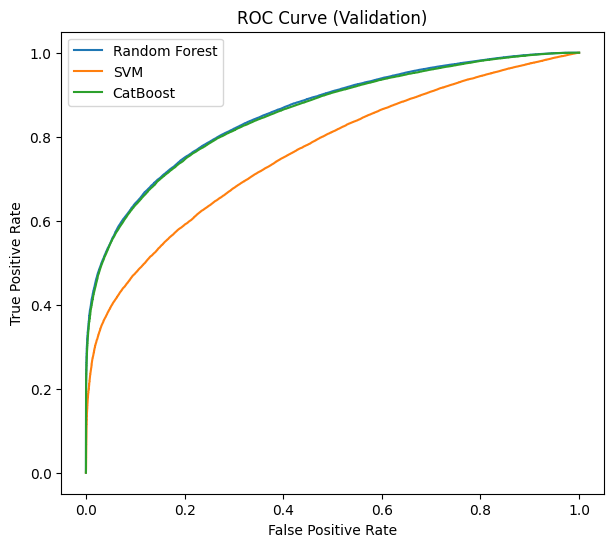

In [17]:
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_val, svm_val_probs)
fpr_cat, tpr_cat, _ = roc_curve(y_val, cat_val_probs)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_cat, tpr_cat, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")

plt.legend()

plt.savefig("../data/roc_curve_ast_scalars_validation.png")

plt.show()

#### ROC for Test data

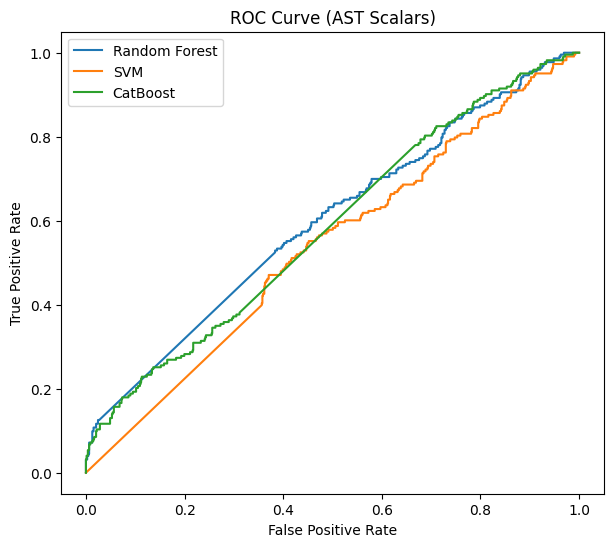

In [18]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_probs)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_cat, tpr_cat, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AST Scalars)")

plt.legend()

plt.savefig("../data/roc_curve_ast_scalars.png")

plt.show()

### SHAP Interpretability

In [19]:
feature_names = [
"max_depth",
"avg_depth",
"depth_var",
"total_nodes",
"leaf_nodes",
"leaf_ratio",
"avg_branch",
"max_children",
"cyclomatic",
"decision_nodes",
"unique_types",
"entropy",
"function_calls",
"unique_calls",
"internal_nodes"
]

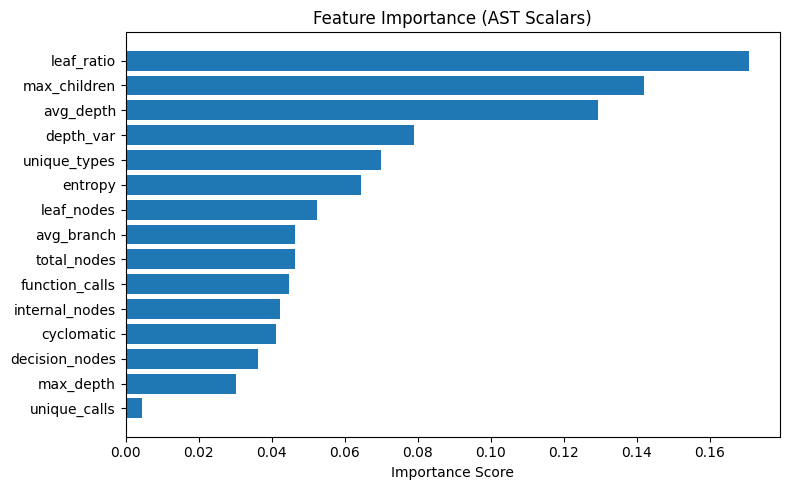

In [20]:


# Feature importance from Random Forest
importances = rf_model.feature_importances_

# Sort features
indices = np.argsort(importances)[::-1]

sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(8,5))
plt.barh(sorted_features, sorted_importances)
plt.gca().invert_yaxis()

plt.title("Feature Importance (AST Scalars)")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.savefig("../data/shap_summary_ast_scalars.png")
plt.show()

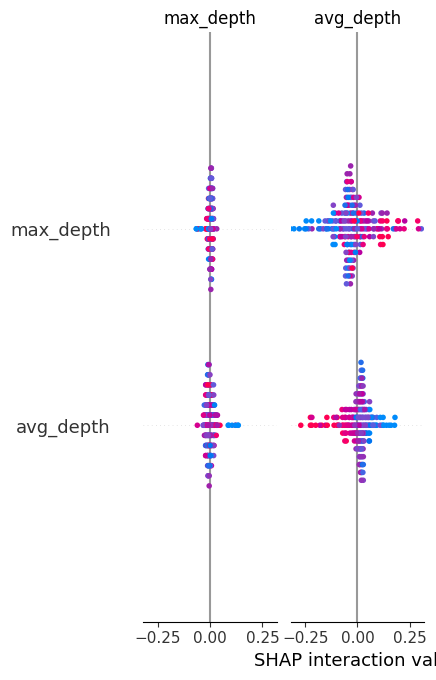

In [22]:
# Random 200 samples from validation set
idx = np.random.choice(len(X_val), 200, replace=False)
X_shap = X_val[idx]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.savefig("../data/shap_summary_ast_scalars.png")

### Model Comparison Table

In [21]:
results = []

for name, model in [
    ("Random Forest", rf_model),
    ("SVM", svm_model),
    ("CatBoost", cat_model)
]:

    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Macro F1": f1_score(y_test, preds, average="macro")
    })

pd.DataFrame(results)

,Model,Accuracy,F1,Macro F1
0,Random Forest,0.359,0.377065,0.358460
1,SVM,0.399,0.351672,0.395780
2,CatBoost,0.362,0.379377,0.361499


We trained classical machine learning models on the 15 AST scalar features extracted from each code snippet.

These features capture structural characteristics of programs such as tree depth, branching patterns, and control-flow complexity.

Unlike lexical models such as TF-IDF, AST features focus on the syntactic shape of the program, enabling the model to detect structural regularities typical of machine-generated code.

This experiment evaluates whether structural programming patterns alone are sufficient for detecting machine-generated code.
AST scalar features capture high-level structural properties of programs,
such as tree depth, branching factor, and control flow complexity.

Random Forest achieved the best validation performance (F1 = 0.77),
suggesting that non-linear interactions between structural features
are important for distinguishing machine-generated code.

However, evaluation on the cross-language test set revealed a large
performance drop (F1 ≈ 0.38), indicating that structural statistics
alone are insufficient for robust cross-language generalization.